# MNIST 数据集预览



In [6]:
from pathlib import Path
import os

# 若从 demo-app/notebooks 打开本文件，将工作目录切到 demo-app（与训练脚本一致）
_here = Path.cwd()
if _here.name == "notebooks" and (_here.parent / "data").exists():
    os.chdir(_here.parent)
elif (_here / "data" / "mnist").exists() or (_here / "pom.xml").exists():
    pass  # 已在 demo-app
else:
    # 从仓库根目录运行时
    _demo = _here / "demo-app"
    if _demo.is_dir():
        os.chdir(_demo)

MNIST_ROOT = Path("data/mnist").resolve()
print("工作目录:", Path.cwd())
print("MNIST 根目录:", MNIST_ROOT)

工作目录: c:\Users\67529\OneDrive\Desktop\number_reco\demo-app
MNIST 根目录: C:\Users\67529\OneDrive\Desktop\number_reco\demo-app\data\mnist


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

# 中文标题、坐标轴：默认 DejaVu Sans 没有汉字字形，会显示成「□□」方框
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "SimSun",
    "Noto Sans CJK SC",
    "PingFang SC",
    "Heiti TC",
    "Arial Unicode MS",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False  # 用 ASCII 减号，避免负号变成方框

# 与展示「原始像素样式」一致：仅转张量，不做随机增强
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_ds = datasets.MNIST(root=str(MNIST_ROOT), train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root=str(MNIST_ROOT), train=False, download=True, transform=transform)

print(f"训练集样本数: {len(train_ds):,}")
print(f"测试集样本数: {len(test_ds):,}")
x0, y0 = train_ds[0]
print(f"单样本张量形状: {tuple(x0.shape)}（C×H×W，MNIST 为 1×28×28）")
print(f"像素取值（归一化后）约落在: [{x0.min().item():.3f}, {x0.max().item():.3f}]")
print(f"标签类型: int，示例标签: {y0}")

训练集样本数: 60,000
测试集样本数: 10,000
单样本张量形状: (1, 28, 28)（C×H×W，MNIST 为 1×28×28）
像素取值（归一化后）约落在: [-0.424, 2.821]
标签类型: int，示例标签: 5


## 每个数字类别各展示一张（从训练集中取每类第一个出现的样本）

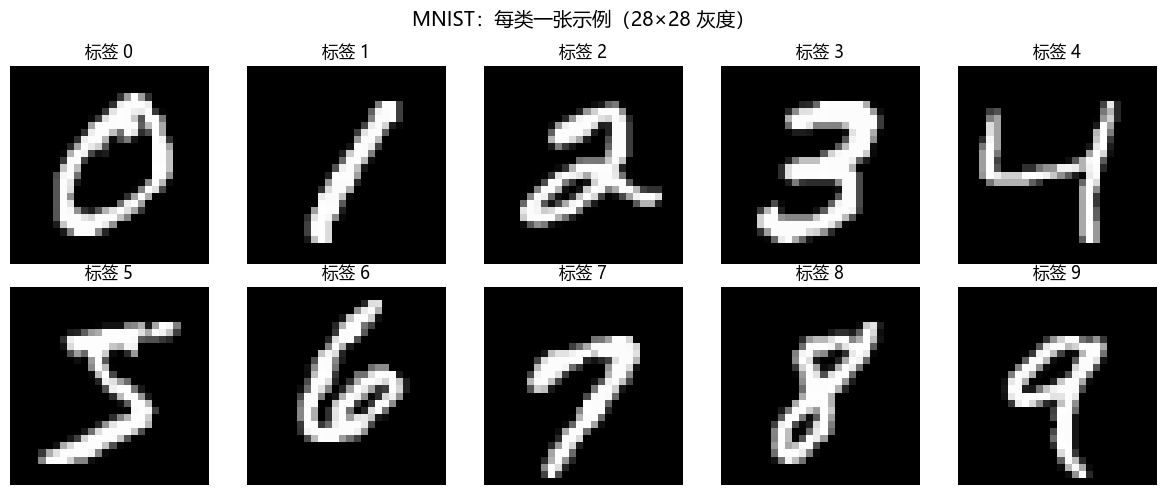

In [8]:
def tensor_to_display_gray(img_tensor):
    """反归一化到 [0,1] 便于 imshow。"""
    t = img_tensor.clone().squeeze(0).numpy()
    t = t * 0.3081 + 0.1307
    return np.clip(t, 0.0, 1.0)


fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
found = {d: None for d in range(10)}
for idx in range(len(train_ds)):
    img, label = train_ds[idx]
    if found[label] is None:
        found[label] = img
    if all(v is not None for v in found.values()):
        break

for d in range(10):
    ax = axes[d]
    ax.imshow(tensor_to_display_gray(found[d]), cmap="gray")
    ax.set_title(f"标签 {d}")
    ax.axis("off")
plt.suptitle("MNIST：每类一张示例（28×28 灰度）", fontsize=14)
plt.tight_layout()
plt.show()

## 随机网格：多看一些样本样式

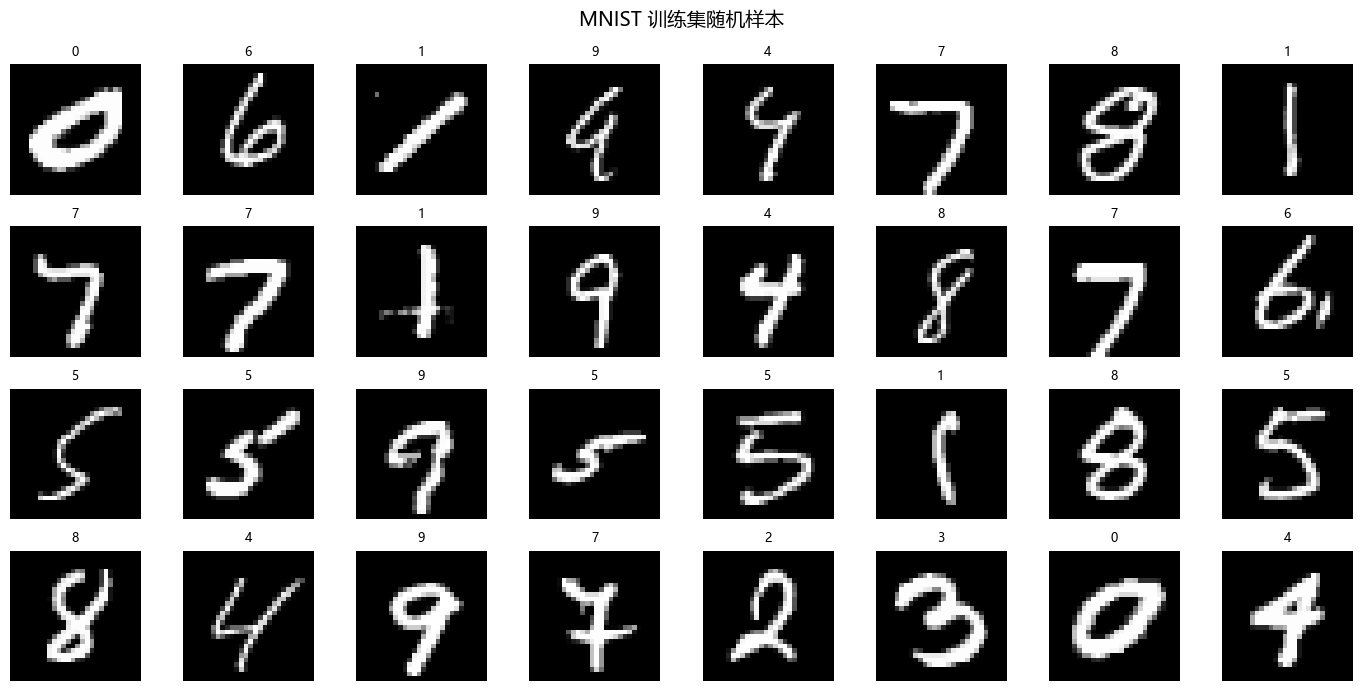

In [9]:
rng = np.random.default_rng(42)
n_rows, n_cols = 4, 8
indices = rng.choice(len(train_ds), size=n_rows * n_cols, replace=False)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7))
for ax, i in zip(axes.flatten(), indices):
    img, label = train_ds[i]
    ax.imshow(tensor_to_display_gray(img), cmap="gray")
    ax.set_title(str(label), fontsize=9)
    ax.axis("off")
plt.suptitle("MNIST 训练集随机样本", fontsize=14)
plt.tight_layout()
plt.show()

## 训练集标签分布（MNIST 各类基本均衡）

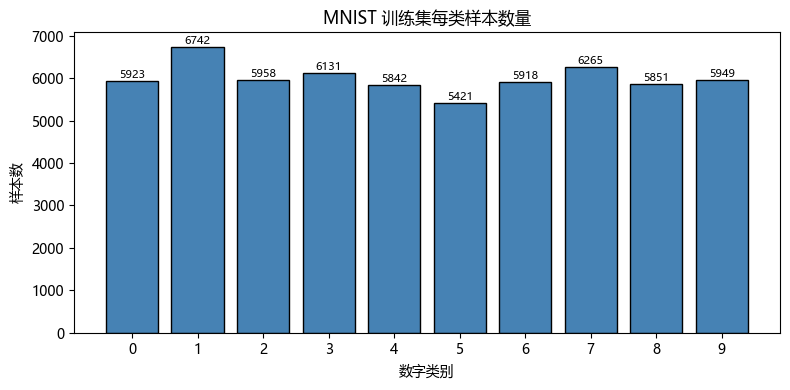

In [10]:
from collections import Counter

labels = [train_ds[i][1] for i in range(len(train_ds))]
cnt = Counter(labels)
digits = sorted(cnt.keys())
counts = [cnt[d] for d in digits]

plt.figure(figsize=(8, 4))
plt.bar(digits, counts, color="steelblue", edgecolor="black")
plt.xticks(digits)
plt.xlabel("数字类别")
plt.ylabel("样本数")
plt.title("MNIST 训练集每类样本数量")
for d, c in zip(digits, counts):
    plt.text(d, c, str(c), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()